In [1]:
from read import fetch_api_data

fetch_api_data()

page 1 loaded!
page 2 loaded!
page 3 loaded!
page 4 loaded!
page 5 loaded!
page 6 loaded!
data fetched successfully
data saved successfully


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



%matplotlib inline

# read data
df = pd.read_csv("user.csv")



In [7]:
# Basic structure info
print("Data Info:")
df.info()




Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          208 non-null    int64  
 1   firstName   208 non-null    object 
 2   lastName    208 non-null    object 
 3   maidenName  60 non-null     object 
 4   age         208 non-null    int64  
 5   gender      208 non-null    object 
 6   email       208 non-null    object 
 7   phone       208 non-null    object 
 8   username    208 non-null    object 
 9   password    208 non-null    object 
 10  birthDate   208 non-null    object 
 11  image       208 non-null    object 
 12  bloodGroup  208 non-null    object 
 13  height      208 non-null    float64
 14  weight      208 non-null    float64
 15  eyeColor    208 non-null    object 
 16  hair        208 non-null    object 
 17  ip          208 non-null    object 
 18  address     208 non-null    object 
 19  macAddress  208 no

In [4]:
print("\nMissing Values:")
print(df.isna().sum())


Missing Values:
id              0
firstName       0
lastName        0
maidenName    148
age             0
gender          0
email           0
phone           0
username        0
password        0
birthDate       0
image           0
bloodGroup      0
height          0
weight          0
eyeColor        0
hair            0
ip              0
address         0
macAddress      0
university      0
bank            0
company         0
ein             0
ssn             0
userAgent       0
crypto          0
role            0
dtype: int64


In [5]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
id              int64
firstName      object
lastName       object
maidenName     object
age             int64
gender         object
email          object
phone          object
username       object
password       object
birthDate      object
image          object
bloodGroup     object
height        float64
weight        float64
eyeColor       object
hair           object
ip             object
address        object
macAddress     object
university     object
bank           object
company        object
ein            object
ssn            object
userAgent      object
crypto         object
role           object
dtype: object


In [8]:
import ast


df_clean = df.copy()


df_clean['birthDate'] = pd.to_datetime(df_clean['birthDate'], errors='coerce')


nested_cols = ['hair', 'address', 'bank', 'company', 'crypto']

for col in nested_cols:
    df_clean[col] = df_clean[col].apply(lambda x: ast.literal_eval(x))

print("Conversion Done")


print("\nHair sample:", df_clean['hair'].iloc[0])
print("\nAddress sample:", df_clean['address'].iloc[0])

Conversion Done

Hair sample: {'color': 'Brown', 'type': 'Curly'}

Address sample: {'address': '626 Main Street', 'city': 'Phoenix', 'state': 'Mississippi', 'stateCode': 'MS', 'postalCode': '29112', 'coordinates': {'lat': -77.16213, 'lng': -92.084824}, 'country': 'United States'}


In [9]:
# expand hair
df_clean['hair_color'] = df_clean['hair'].apply(lambda x: x.get('color'))
df_clean['hair_type'] = df_clean['hair'].apply(lambda x: x.get('type'))

# expand address
df_clean['street_address'] = df_clean['address'].apply(lambda x: x.get('address'))
df_clean['city'] = df_clean['address'].apply(lambda x: x.get('city'))
df_clean['state'] = df_clean['address'].apply(lambda x: x.get('state'))
df_clean['state_code'] = df_clean['address'].apply(lambda x: x.get('stateCode'))
df_clean['postal_code'] = df_clean['address'].apply(lambda x: x.get('postalCode'))
df_clean['country'] = df_clean['address'].apply(lambda x: x.get('country'))
df_clean['lat'] = df_clean['address'].apply(lambda x: x.get('coordinates', {}).get('lat'))
df_clean['lng'] = df_clean['address'].apply(lambda x: x.get('coordinates', {}).get('lng'))

# expand bank
df_clean['card_expire'] = df_clean['bank'].apply(lambda x: x.get('cardExpire'))
df_clean['card_type'] = df_clean['bank'].apply(lambda x: x.get('cardType'))
df_clean['currency'] = df_clean['bank'].apply(lambda x: x.get('currency'))
df_clean['iban'] = df_clean['bank'].apply(lambda x: x.get('iban'))

# expand company
df_clean['company_department'] = df_clean['company'].apply(lambda x: x.get('department'))
df_clean['company_name'] = df_clean['company'].apply(lambda x: x.get('name'))
df_clean['job_title'] = df_clean['company'].apply(lambda x: x.get('title'))
df_clean['company_city'] = df_clean['company'].apply(lambda x: x.get('address', {}).get('city'))
df_clean['company_state'] = df_clean['company'].apply(lambda x: x.get('address', {}).get('state'))

# expand crypto
df_clean['crypto_coin'] = df_clean['crypto'].apply(lambda x: x.get('coin'))
df_clean['crypto_network'] = df_clean['crypto'].apply(lambda x: x.get('network'))

print("New shape:", df_clean.shape)

new_cols = [
    'hair_color', 'hair_type', 'city', 'state', 'country',
    'lat', 'lng', 'card_type', 'currency',
    'company_department', 'company_name', 'job_title',
    'crypto_coin', 'crypto_network'
]

display(df_clean[new_cols].head())

New shape: (208, 49)


,hair_color,hair_type,city,state,country,lat,lng,card_type,currency,company_department,company_name,job_title,crypto_coin,crypto_network
0,Brown,Curly,Phoenix,Mississippi,United States,-77.162130,-92.084824,Diners Club International,GBP,Engineering,"Dooley, Kozey and Cronin",Sales Manager,Bitcoin,Ethereum (ERC20)
1,Green,Straight,Houston,Alabama,United States,22.815468,115.608581,JCB,USD,Support,Spinka - Dickinson,Support Specialist,Bitcoin,Ethereum (ERC20)
2,White,Wavy,Washington,Alabama,United States,45.289366,46.832664,Discover,EUR,Research and Development,Schiller - Zieme,Accountant,Bitcoin,Ethereum (ERC20)
3,Blonde,Straight,Seattle,Pennsylvania,United States,16.782513,-139.347230,Mastercard,CAD,Support,Pagac and Sons,Research Analyst,Bitcoin,Ethereum (ERC20)
4,White,Straight,Jacksonville,Colorado,United States,0.505589,-157.432810,Mastercard,NZD,Human Resources,Graham - Gulgowski,Quality Assurance Engineer,Bitcoin,Ethereum (ERC20)


In [10]:
# Create full name
df_clean['full_name'] = df_clean['firstName'] + " " + df_clean['lastName']


# Descriptive Statistics


Numerical features (age, height, weight)

In [11]:
print("Numerical Summary:")
display(df_clean[['age', 'height', 'weight']].describe())

Numerical Summary:


,age,height,weight
count,208.000000,208.000000,208.000000
mean,33.139423,175.720240,75.038606
std,5.544269,14.119984,14.090775
min,23.000000,150.250000,50.100000
25%,29.000000,164.187500,62.547500
50%,32.000000,177.430000,75.985000
75%,36.000000,186.960000,86.992500
max,46.000000,199.810000,99.540000


Gender distribution

In [12]:
print("\nGender Distribution:")
display(df_clean['gender'].value_counts())


Gender Distribution:


female    106
male      102
Name: gender, dtype: int64

Role distribution

In [13]:
print("\nRole Distribution:")
display(df_clean['role'].value_counts())


Role Distribution:


user         193
moderator     10
admin          5
Name: role, dtype: int64

Top states distribution

In [14]:

print("\nTop 10 States:")
display(df_clean['state'].value_counts().head(10))


Top 10 States:


Arkansas         10
West Virginia     8
New Hampshire     8
Vermont           8
Utah              8
Mississippi       7
Delaware          7
Maryland          6
Idaho             6
Montana           6
Name: state, dtype: int64

# 🗺 Top 10 States

This chart shows the states with the highest number of users.


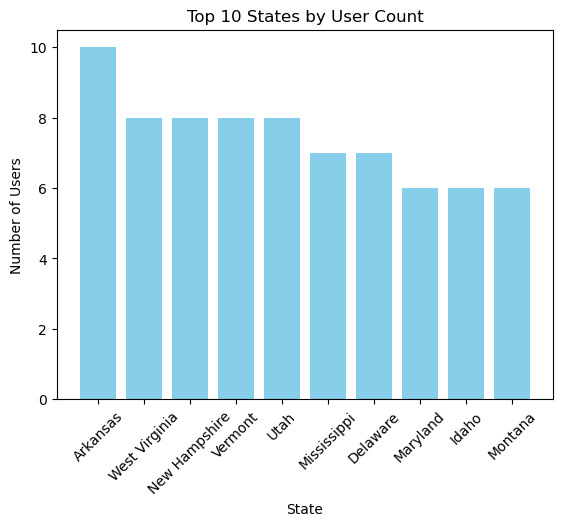

In [15]:
top_states = df_clean['state'].value_counts().head(10)

plt.figure()

plt.bar(top_states.index, top_states.values, color='skyblue')

plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Number of Users")
plt.title("Top 10 States by User Count")

plt.show()

#  Which Age Group Has the Most Users?

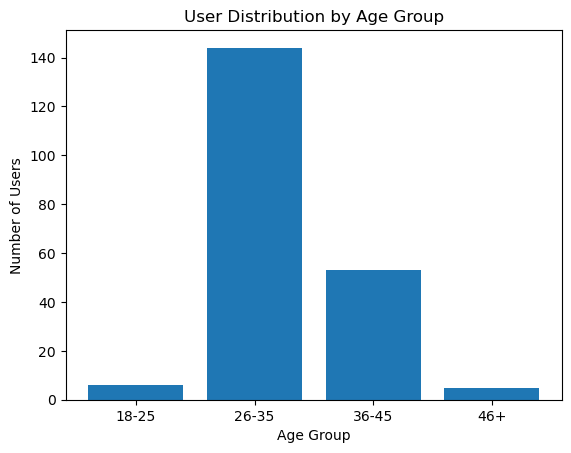

18-25      6
26-35    144
36-45     53
46+        5
Name: age_group, dtype: int64

In [16]:


bins = [18, 25, 35, 45, 100]
labels = ['18-25', '26-35', '36-45', '46+']

df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=True)


age_counts = df_clean['age_group'].value_counts().sort_index()

plt.figure()
plt.bar(age_counts.index.astype(str), age_counts.values)

plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.title("User Distribution by Age Group")

plt.show()

age_counts

#  What is the Gender Distribution of Users?

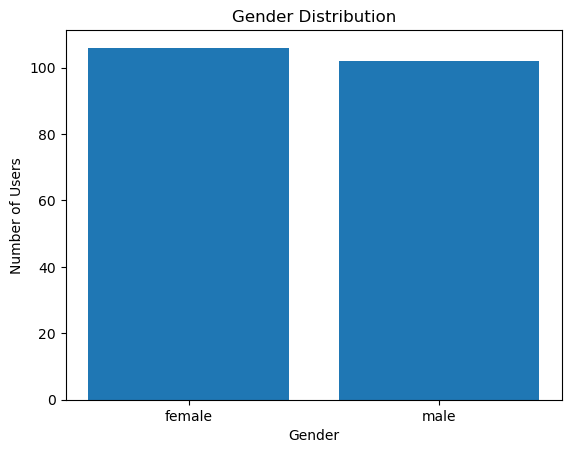

female    106
male      102
Name: gender, dtype: int64

In [17]:
gender_counts = df_clean['gender'].value_counts()

plt.figure()
plt.bar(gender_counts.index, gender_counts.values)

plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.title("Gender Distribution")

plt.show()

gender_counts

# What is the Distribution of User Roles?

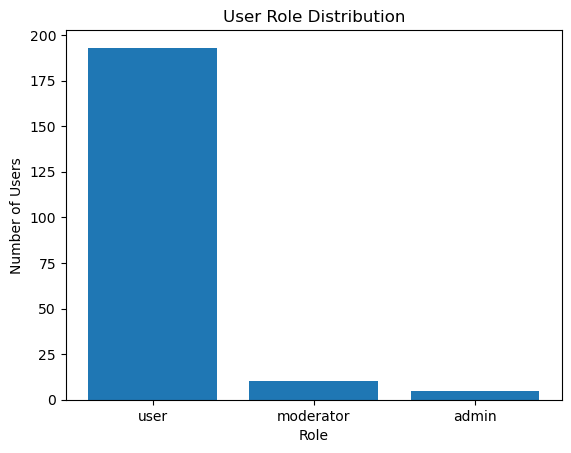

user         193
moderator     10
admin          5
Name: role, dtype: int64

In [18]:
role_counts = df_clean['role'].value_counts()

plt.figure()
plt.bar(role_counts.index, role_counts.values)

plt.xlabel("Role")
plt.ylabel("Number of Users")
plt.title("User Role Distribution")

plt.show()

role_counts

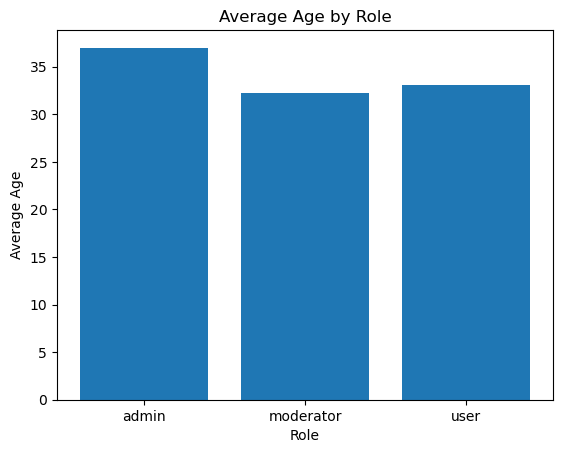

role
admin        37.000000
moderator    32.200000
user         33.088083
Name: age, dtype: float64

In [19]:

avg_age_role = df_clean.groupby('role')['age'].mean()

plt.figure()
plt.bar(avg_age_role.index, avg_age_role.values)

plt.xlabel("Role")
plt.ylabel("Average Age")
plt.title("Average Age by Role")

plt.show()

avg_age_role

# Which Company Departments Have the Most Users?

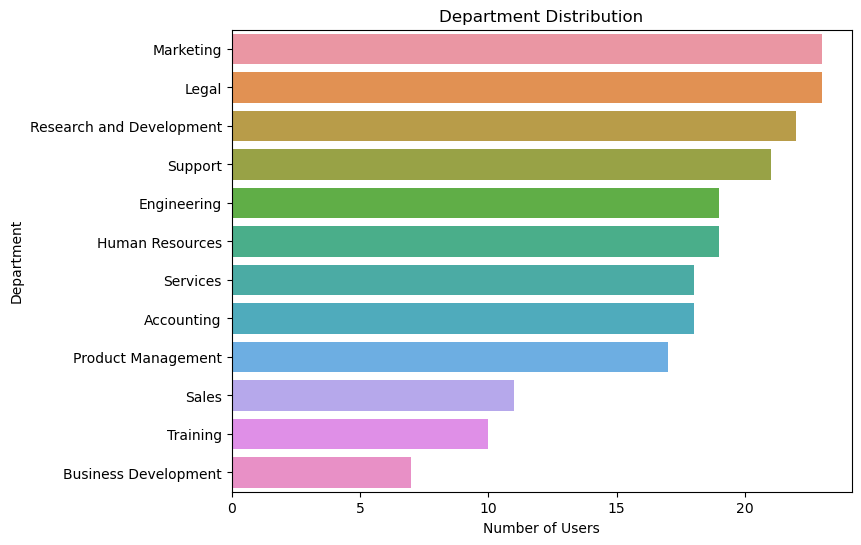

Marketing                   23
Legal                       23
Research and Development    22
Support                     21
Engineering                 19
Human Resources             19
Services                    18
Accounting                  18
Product Management          17
Sales                       11
Training                    10
Business Development         7
Name: company_department, dtype: int64

In [24]:

dept_counts = df_clean['company_department'].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=dept_counts.values,
    y=dept_counts.index
)

plt.xlabel("Number of Users")
plt.ylabel("Department")
plt.title("Department Distribution")

plt.show()

dept_counts

#  Which Universities Appear Most Frequently?

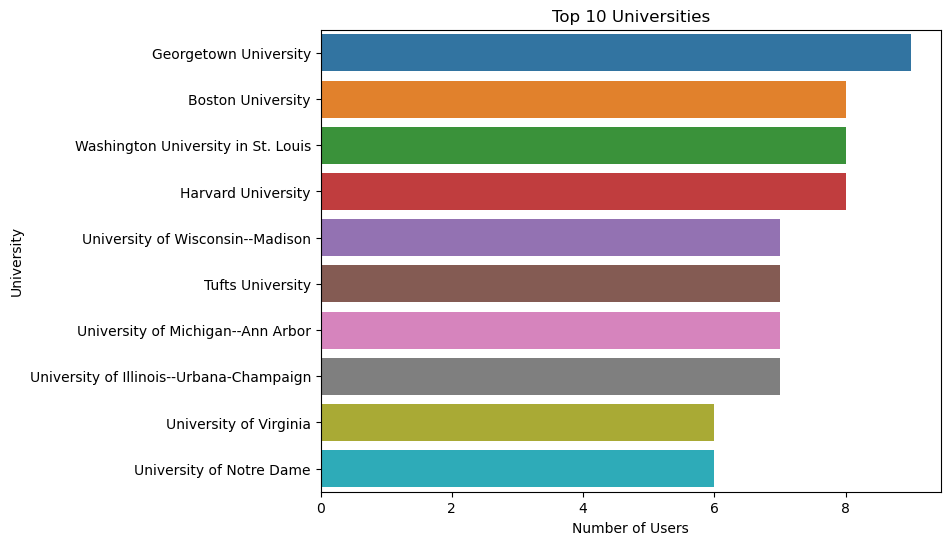

Georgetown University                       9
Boston University                           8
Washington University in St. Louis          8
Harvard University                          8
University of Wisconsin--Madison            7
Tufts University                            7
University of Michigan--Ann Arbor           7
University of Illinois--Urbana-Champaign    7
University of Virginia                      6
University of Notre Dame                    6
Name: university, dtype: int64

In [22]:
import seaborn as sns



top_universities = df_clean['university'].value_counts().head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_universities.values,
    y=top_universities.index
)

plt.xlabel("Number of Users")
plt.ylabel("University")
plt.title("Top 10 Universities")

plt.show()

top_universities

# Correlation Analysis

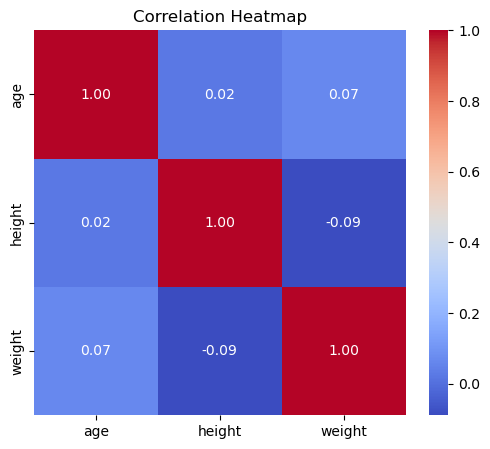

,age,height,weight
age,1.000000,0.023458,0.067026
height,0.023458,1.000000,-0.088655
weight,0.067026,-0.088655,1.000000


In [25]:

numeric_cols = df_clean[['age', 'height', 'weight']]


corr_matrix = numeric_cols.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

corr_matrix

 # How Are Roles Distributed Across Departments?

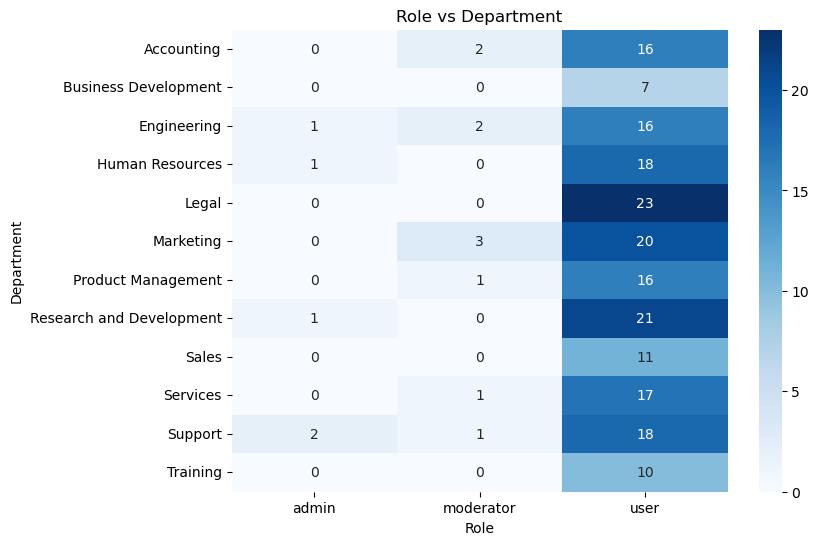

In [27]:

role_dept = pd.crosstab(df_clean['company_department'], df_clean['role'])

plt.figure(figsize=(8,6))

sns.heatmap(
    role_dept,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Role vs Department")
plt.xlabel("Role")
plt.ylabel("Department")

plt.show()

